In [460]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [461]:
df_new=pd.read_csv(r"D:\AI ECHO\newdata.csv")
df_new.head()

,Name,Rating,Comment,Date,Country,Thumbs Up,Review ID,App Version
0,Musa Maan,4,pictures information is not good but overall best,2024-07-18 18:19:22,us,0,4312ea55-28b5-4abd-b007-c0c4909c25bc,1.2024.192
1,Lorax,5,Very useful,2024-07-18 18:18:15,us,0,249e38e0-9d3a-4392-896d-88fd7e4499f6,NaN
2,Ramesh Singh,5,This app is very good for students who are str...,2024-07-18 18:18:00,us,0,d1ad5cbb-29c1-468b-8e00-31d82f4ee943,1.2024.192
3,Gurjaap Singh,3,limited chats😤,2024-07-18 18:15:15,us,0,6142e817-ac9a-4beb-aa8b-6ed8a273ed82,1.2024.157
4,Riya Sharma,3,i like this app very muchh ❤️❤️❤️,2024-07-18 18:11:52,us,0,10f2a957-df4c-4a2a-b71d-a5dfb54e2ed3,1.2024.192


In [462]:
df_new.shape

(100000, 8)

In [463]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Name         100000 non-null  object
 1   Rating       100000 non-null  int64 
 2   Comment      100000 non-null  object
 3   Date         100000 non-null  object
 4   Country      100000 non-null  object
 5   Thumbs Up    100000 non-null  int64 
 6   Review ID    100000 non-null  object
 7   App Version  93268 non-null   object
dtypes: int64(2), object(6)
memory usage: 6.1+ MB


In [464]:
df_new.isnull().sum()

Name              0
Rating            0
Comment           0
Date              0
Country           0
Thumbs Up         0
Review ID         0
App Version    6732
dtype: int64

In [465]:
df_new.duplicated().sum()

np.int64(0)

In [466]:
df_new = df_new.dropna(subset=['Comment', 'Rating'])

In [467]:
df_new=df_new.drop(columns=['Name', 'Date', 'Country', 'Thumbs Up', 'Review ID', 'App Version'])

In [468]:
df_new.head()

,Rating,Comment
0,4,pictures information is not good but overall best
1,5,Very useful
2,5,This app is very good for students who are str...
3,3,limited chats😤
4,3,i like this app very muchh ❤️❤️❤️


In [469]:
df_new.shape

(100000, 2)

In [470]:
def get_sentiment(rating):
    if rating >= 4:
        return "positive"
    elif rating == 3:
        return "neutral"
    else:
        return "negative"

df_new['sentiment'] = df_new['Rating'].apply(get_sentiment)

In [471]:
df_new['sentiment'].value_counts()

sentiment
positive    86780
negative     8813
neutral      4407
Name: count, dtype: int64

In [472]:
import re
import string
import emoji

def clean_text(text):
    text = str(text).lower()
    
    # convert emoji → remove (use replace='' to remove)
    text = emoji.replace_emoji(text, replace='')
    
    # remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # remove emails
    text = re.sub(r'\S+@\S+', '', text)
    
    # remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # remove numbers
    text = re.sub(r'\d+', '', text)
    
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# apply cleaning
df_new['clean_comment'] = df_new['Comment'].apply(clean_text)

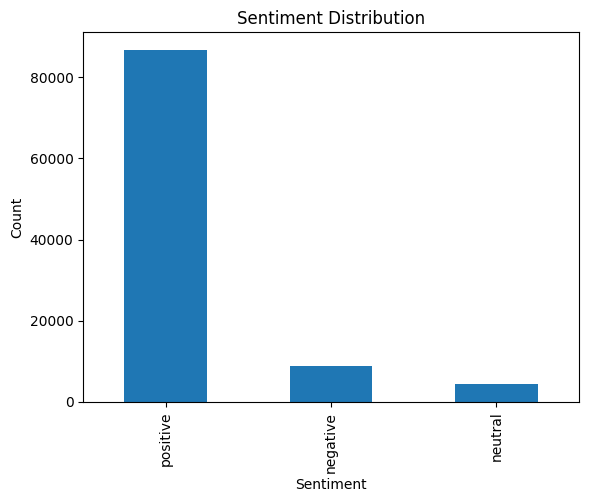

In [473]:
import matplotlib.pyplot as plt

df_new['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

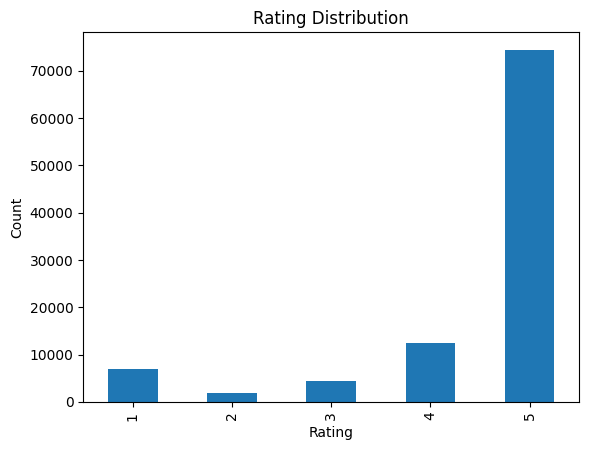

In [474]:
df_new['Rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

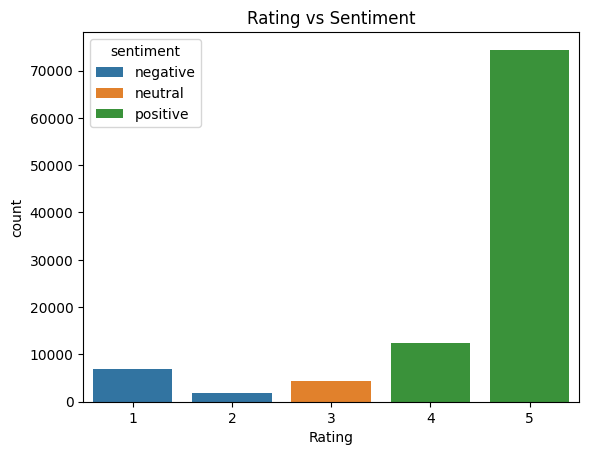

In [475]:
import seaborn as sns

sns.countplot(x='Rating', hue='sentiment', data=df_new)
plt.title("Rating vs Sentiment")
plt.show()

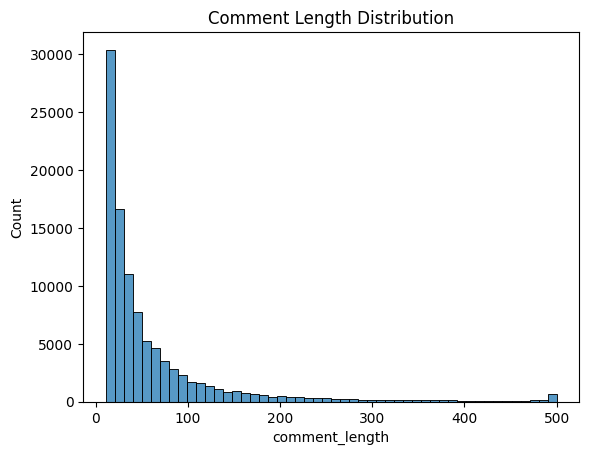

In [476]:
df_new['comment_length'] = df_new['Comment'].apply(len)

sns.histplot(df_new['comment_length'], bins=50)
plt.title("Comment Length Distribution")
plt.show()

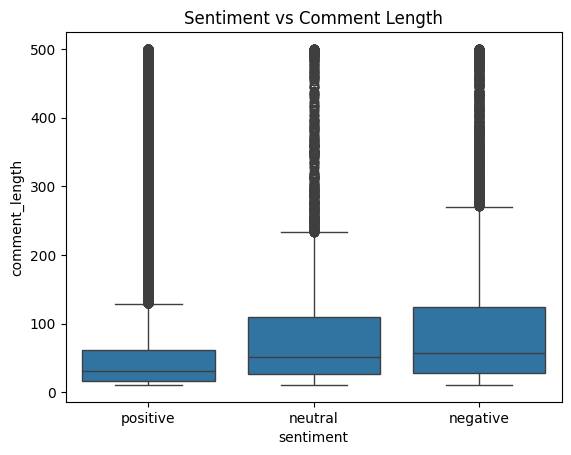

In [477]:
sns.boxplot(x='sentiment', y='comment_length', data=df_new)
plt.title("Sentiment vs Comment Length")
plt.show()

In [478]:
from collections import Counter

all_words = " ".join(df_new['clean_comment']).split()
common_words = Counter(all_words).most_common(10)

print(common_words)

[('it', 35832), ('app', 32885), ('the', 30507), ('i', 29692), ('is', 28274), ('and', 28016), ('to', 26163), ('very', 25258), ('this', 22089), ('a', 19949)]


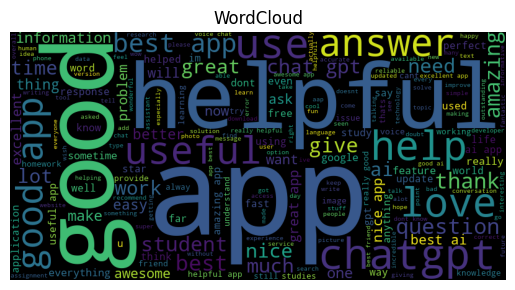

In [479]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400).generate(" ".join(df_new['clean_comment']))

plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud")
plt.show()

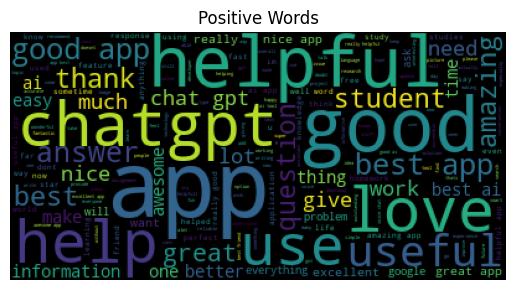

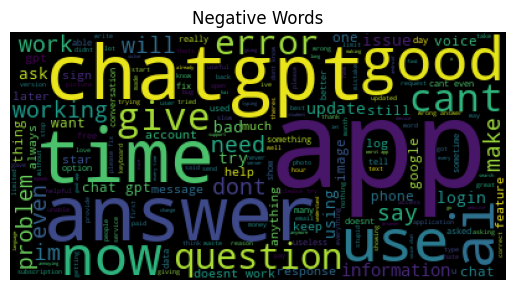

In [480]:
positive_words = " ".join(df_new[df_new['sentiment']=='positive']['clean_comment'])
negative_words = " ".join(df_new[df_new['sentiment']=='negative']['clean_comment'])

wc_pos = WordCloud().generate(positive_words)
wc_neg = WordCloud().generate(negative_words)

plt.imshow(wc_pos)
plt.title("Positive Words")
plt.axis("off")
plt.show()

plt.imshow(wc_neg)
plt.title("Negative Words")
plt.axis("off")
plt.show()

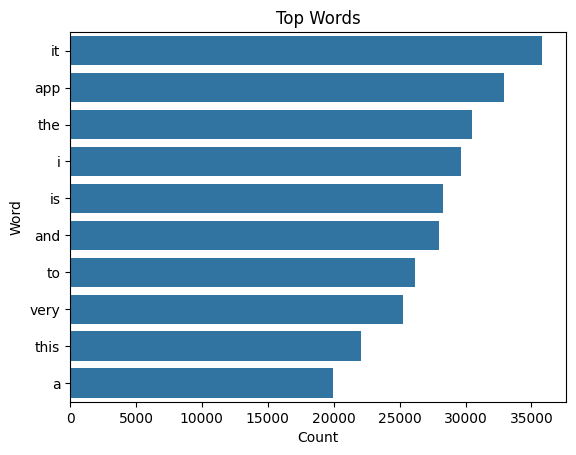

In [481]:
common_df = pd.DataFrame(common_words, columns=['Word', 'Count'])

sns.barplot(x='Count', y='Word', data=common_df)
plt.title("Top Words")
plt.show()

In [482]:
X = df_new['clean_comment']
y = df_new['sentiment']

In [483]:
# Separate classes
df_pos = df_new[df_new['sentiment'] == 'positive']
df_neg = df_new[df_new['sentiment'] == 'negative']
df_neu = df_new[df_new['sentiment'] == 'neutral']

# Sample properly
df_pos_sample = df_pos.sample(n=8000, random_state=42)

df_neg_sample = df_neg.sample(n=8000, random_state=42)

# 🔥 IMPORTANT FIX (use replace=True)
df_neu_sample = df_neu.sample(n=8000, replace=True, random_state=42)

# Combine
df_balanced = pd.concat([df_pos_sample, df_neg_sample, df_neu_sample])

In [484]:
df_balanced['sentiment'].value_counts()

sentiment
positive    8000
negative    8000
neutral     8000
Name: count, dtype: int64

In [485]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

X = tfidf.fit_transform(X)

In [486]:
print(type(X))  

<class 'scipy.sparse._csr.csr_matrix'>


In [487]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [488]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [489]:
y_pred_lr = model.predict(X_test)

In [490]:
from sklearn.metrics import classification_report

y_pred_lr = model.predict(X_test)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

    negative       0.50      0.69      0.58      1773
     neutral       0.12      0.38      0.19       914
    positive       0.96      0.82      0.89     17313

    accuracy                           0.79     20000
   macro avg       0.53      0.63      0.55     20000
weighted avg       0.89      0.79      0.83     20000



[[ 1222   323   228]
 [  279   343   292]
 [  944  2114 14255]]


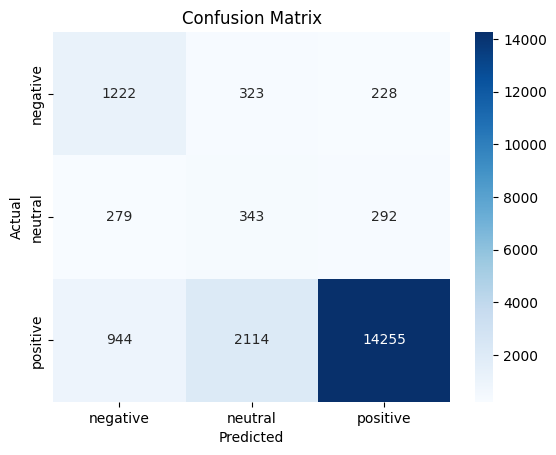

In [491]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

labels = ['negative', 'neutral', 'positive']
cm_df_new = pd.DataFrame(cm, index=labels, columns=labels)

sns.heatmap(cm_df_new, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [492]:
from sklearn.ensemble import RandomForestClassifier

In [493]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [494]:
y_pred_rf = rf_model.predict(X_test)

In [495]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

    negative       0.70      0.42      0.53      1773
     neutral       0.04      0.01      0.02       914
    positive       0.90      0.97      0.94     17313

    accuracy                           0.88     20000
   macro avg       0.55      0.47      0.49     20000
weighted avg       0.85      0.88      0.86     20000



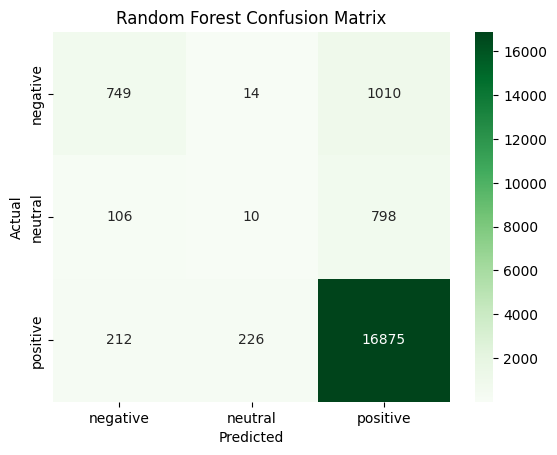

In [496]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [497]:
from sklearn.naive_bayes import MultinomialNB

In [498]:
nb_model = MultinomialNB(alpha=0.5)
nb_model.fit(X_train, y_train)

,alpha,0.5
,force_alpha,True
,fit_prior,True
,class_prior,None


In [499]:
y_pred_nb = nb_model.predict(X_test)

In [500]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

    negative       0.62      0.57      0.59      1773
     neutral       0.32      0.04      0.08       914
    positive       0.92      0.97      0.95     17313

    accuracy                           0.89     20000
   macro avg       0.62      0.53      0.54     20000
weighted avg       0.87      0.89      0.88     20000



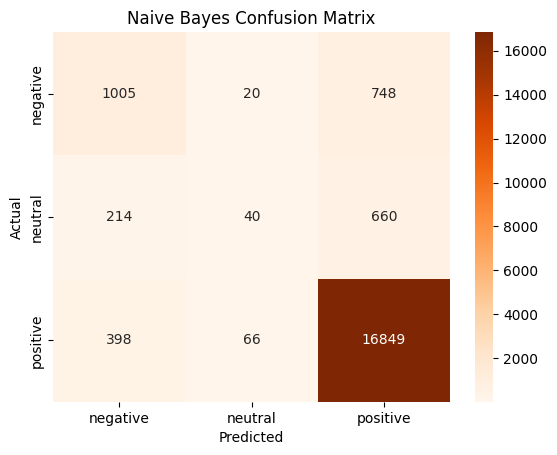

In [501]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [502]:
# ==============================
# 1. Import Models
# ==============================
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score
import pandas as pd


# ==============================
# 2. Initialize Models
# ==============================
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
nb = MultinomialNB(alpha=0.5)
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)


# ==============================
# 3. Train Models
# ==============================
lr.fit(X_train, y_train)
nb.fit(X_train, y_train)
rf.fit(X_train, y_train)


# ==============================
# 4. Predictions
# ==============================
y_pred_lr = lr.predict(X_test)
y_pred_nb = nb.predict(X_test)
y_pred_rf = rf.predict(X_test)


# ==============================
# 5. Evaluation Metrics
# ==============================
models = ['Logistic Regression', 'Naive Bayes', 'Random Forest']

accuracy = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_rf)
]

f1 = [
    f1_score(y_test, y_pred_lr, average='weighted'),
    f1_score(y_test, y_pred_nb, average='weighted'),
    f1_score(y_test, y_pred_rf, average='weighted')
]


# ==============================
# 6. Create Comparison Table
# ==============================
comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'F1 Score': f1
})

print(comparison_df)

                 Model  Accuracy  F1 Score
0  Logistic Regression    0.7910  0.828977
1          Naive Bayes    0.8947  0.876170
2        Random Forest    0.8817  0.859182


In [503]:
import pickle

pickle.dump(model, open("sentiment_model1.pkl", "wb"))
pickle.dump(tfidf, open("tfidf_vectorizer1.pkl", "wb"))